In [1]:
!pip install scienceplots --quiet
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, Normalizer, MaxAbsScaler, QuantileTransformer, PowerTransformer
from sklearn.metrics import classification_report, mean_squared_error, r2_score
from sklearn.base import is_classifier, is_regressor
from sklearn.base import BaseEstimator, TransformerMixin
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pickle as pkl
import os
import scienceplots
plt.style.use(['science','no-latex'])
plt.rcParams['font.size'] = 16

In [2]:
dataset_path = "/content/drive/MyDrive/ML Dataset/Transmission Datasets/exoCNN/"
print("Loading files...")
X = np.load(dataset_path+'trans_type1.npy')
Y = np.load(dataset_path+'parameters_type1.npy')[:, :2]
md = pkl.load(open(dataset_path+'metadata.p', 'rb'))
wl_grid = md['Wavelength']['NIRSPEC']
print("Files loaded")
print("-"*10)
print(f"Spectra shape: {X.shape}")
print(f"Labels shape: {Y.shape}")

Loading files...
Files loaded
----------
Spectra shape: (76465, 403)
Labels shape: (76465, 2)


In [3]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class StatefulRowStandardScaler(BaseEstimator, TransformerMixin):
    """Row-wise (instance) standardizer with stateful inverse_transform."""

    def __init__(self, copy: bool = True):
        self.copy = copy

    def fit(self, X, y=None):
        """Validate input and store feature count."""
        X = np.asarray(X)
        self.n_features_in_ = X.shape[1] if X.ndim > 0 else 1
        self._input_was_1d = (X.ndim == 1)
        return self

    def transform(self, X):
        X = np.asarray(X)

        # Handle 1D case
        was_1d = X.ndim == 1
        if was_1d:
            X = X.reshape(1, -1)

        # Compute stats
        mean = X.mean(axis=1, keepdims=True)
        std = X.std(axis=1, keepdims=True)
        std = np.where(std == 0, 1.0, std)  # Avoid div by zero

        # Store state
        self.last_mean_ = mean
        self.last_std_ = std

        X_scaled = (X - mean) / std
        return X_scaled.flatten() if was_1d else X_scaled

    def inverse_transform(self, X):
        if self.last_mean_ is None:
            raise ValueError("transform() must be called before inverse_transform()")

        if X.shape[0] != self.last_mean_.shape[0]:
            raise ValueError(
                f"Shape mismatch: X has {X.shape[0]} rows, "
                f"stored stats have {self.last_mean_.shape[0]}"
            )

        X = np.asarray(X)
        return (X * self.last_std_) + self.last_mean_


In [13]:
class MLTrainer:
    def __init__(self, model, feature_scaler='standard', target_scaler=None,
                 random_state=42, verbose=True):
        self.model = model
        self.feature_scaler_type = feature_scaler.lower() if feature_scaler else None
        self.target_scaler_type = target_scaler.lower() if target_scaler else None
        self.random_state = random_state
        self.verbose = verbose

        self.scaler_x = None
        self.scaler_y = None

        self.X_train, self.X_val, self.X_test = None, None, None
        self.y_train, self.y_val, self.y_test = None, None, None
        self.y_test_orig = None

        # Store feature/target names
        self.feature_names_in_ = None
        self.target_names_ = None

        # Store optimization results
        self.best_params_ = None
        self.cv_results_ = None

    def _get_scaler(self, scaler_name):
        scalers = {
            'standard': StandardScaler(),
            'minmax': MinMaxScaler(),
            'robust': RobustScaler(),
            'row_wise': StatefulRowStandardScaler(),
            'normalizer': Normalizer(),
            'maxabs': MaxAbsScaler(),
            'quantile': QuantileTransformer(),
            'power': PowerTransformer()
        }
        return scalers.get(scaler_name, StandardScaler())

    def _is_xgboost(self):
        """Check if model is XGBoost."""
        try:
            import xgboost
            return isinstance(self.model, xgboost.XGBModel)
        except ImportError:
            return 'XGB' in self.model.__class__.__name__

    def _to_numpy(self, data):
        """Convert pandas DataFrame/Series to numpy array."""
        if hasattr(data, 'values'):
            return data.values
        return np.array(data)

    def run(self, X, y, test_size=0.2, val_size=0.2):
        if self.verbose:
            print(f"--- Starting Regression Pipeline with {self.model.__class__.__name__} ---")

        # Store feature/target names
        self.feature_names_in_ = X.columns.tolist() if hasattr(X, 'columns') else None
        self.target_names_ = y.columns.tolist() if hasattr(y, 'columns') else None

        # Convert to numpy early
        X = self._to_numpy(X)
        y = self._to_numpy(y)

        # 1. Split Data
        X_remain, X_test, y_remain, y_test = train_test_split(
            X, y, test_size=test_size, random_state=self.random_state
        )
        rel_val = val_size / (1 - test_size)
        self.X_train, self.X_val, self.y_train, self.y_val = train_test_split(
            X_remain, y_remain, test_size=rel_val, random_state=self.random_state
        )
        self.y_train = self.y_train[:, :2]
        self.y_val = self.y_val[:, :2]

        self.y_test_orig = y_test.copy()
        self.X_test = X_test
        self.y_test = y_test[:, :2]

        # 2. Scale Features (fit on train only)
        if self.feature_scaler_type:
            self.scaler_x = self._get_scaler(self.feature_scaler_type)
            self.X_train = self.scaler_x.fit_transform(self.X_train)
            self.X_val = self.scaler_x.transform(self.X_val)
            self.X_test = self.scaler_x.transform(self.X_test)

        # 3. Scale Target (Regression)
        if self.target_scaler_type:
            self.scaler_y = self._get_scaler(self.target_scaler_type)

            def transform_y(y_data, fit=False):

                # Ensure 2D for scaling
                y_r = np.asarray(y_data)
                if y_r.ndim == 1:
                    y_r = y_r.reshape(-1, 1)

                # Handle Multi-output case
                if y_r.shape[1] > 1:
                    if fit:
                        return self.scaler_y.fit_transform(y_r)
                    return self.scaler_y.transform(y_r)
                else:
                    # Single output
                    if fit:
                        return self.scaler_y.fit_transform(y_r).ravel()
                    return self.scaler_y.transform(y_r).ravel()

            self.y_train = transform_y(self.y_train, fit=True)
            self.y_val = transform_y(self.y_val)
            self.y_test = transform_y(self.y_test)

            # Flatten back for training compatibility if needed
            if self.y_train.ndim > 1 and self.y_train.shape[1] == 1:
                self.y_train = self.y_train.ravel()
                self.y_val = self.y_val.ravel()
                self.y_test = self.y_test.ravel()

        # 4. Train
        self._train_model()

        self._evaluate()
        return self

    def _train_model(self):
        """Internal method to train the model."""
        if self._is_xgboost():
            # Using eval_set for early stopping support in XGBoost Regressor
            self.model.fit(
                self.X_train, self.y_train,
                eval_set=[(self.X_val, self.y_val)],
                verbose=False
            )
        else:
            self.model.fit(self.X_train, self.y_train)

    def optimize_hyperparameters(self, param_grid, method='grid', cv=5,
                                 scoring='neg_mean_squared_error', n_iter=30,
                                 random_state=None, n_jobs=-1):
        """
        Optimize hyperparameters using GridSearchCV or RandomizedSearchCV.

        Parameters:
        -----------
        param_grid : dict
            Dictionary with parameters names (string) as keys and lists of
            parameter settings to try as values.
        method : str, default='grid'
            Optimization method: 'grid' for GridSearchCV or 'random' for RandomizedSearchCV.
        cv : int, default=5
            Number of folds in cross-validation.
        scoring : str, default='neg_mean_squared_error'
            Scoring metric. Options: 'neg_mean_squared_error', 'neg_mean_absolute_error', 'r2'.
        n_iter : int, default=30
            Number of parameter settings sampled in RandomizedSearchCV. Ignored for GridSearchCV.
        random_state : int, optional
            Random state for RandomizedSearchCV. Defaults to self.random_state.
        n_jobs : int, default=-1
            Number of jobs to run in parallel.

        Returns:
        --------
        self
            The fitted model is updated with best parameters.
        """
        if random_state is None:
            random_state = self.random_state

        if self.X_train is None or self.y_train is None:
            raise ValueError("Training data not found. Run 'run()' first.")

        if self.verbose:
            print(f"--- Starting Hyperparameter Optimization ({method.capitalize()}SearchCV) ---")

        # Select optimization method
        if method == 'grid':
            search = GridSearchCV(
                estimator=self.model,
                param_grid=param_grid,
                scoring=scoring,
                cv=cv,
                n_jobs=n_jobs,
                verbose=1 if self.verbose else 0,
                return_train_score=True
            )
        elif method == 'random':
            search = RandomizedSearchCV(
                estimator=self.model,
                param_distributions=param_grid,
                n_iter=n_iter,
                scoring=scoring,
                cv=cv,
                n_jobs=n_jobs,
                random_state=random_state,
                verbose=1 if self.verbose else 0,
                return_train_score=True
            )
        else:
            raise ValueError("Invalid method. Use 'grid' or 'random'.")

        # Fit the search
        search.fit(self.X_train, self.y_train, eval_set=[(self.X_val, self.y_val)])

        # Update model with best parameters
        self.model = search.best_estimator_
        self.best_params_ = search.best_params_
        self.cv_results_ = search.cv_results_

        if self.verbose:
            print(f"Best Parameters: {self.best_params_}")
            print(f"Best CV Score ({scoring}): {search.best_score_:.4f}")

        # Re-evaluate on validation set with best params
        self._train_model()
        self._evaluate()

        return self

    def plot_optimization_results(self, param_name, save_path=None):
        """
        Plot the optimization results for a specific hyperparameter.

        Parameters:
        -----------
        param_name : str
            The name of the hyperparameter to plot.
        save_path : str, optional
            Path to save the figure.
        """
        if self.cv_results_ is None:
            raise ValueError("No optimization results available. Run 'optimize_hyperparameters()' first.")

        # Get results for the specific parameter
        param_key = f'param_{param_name}'

        if param_key not in self.cv_results_:
            raise ValueError(f"Parameter '{param_name}' not found in optimization results.")

        param_values = self.cv_results_[param_key]
        mean_test_scores = self.cv_results_['mean_test_score']
        std_test_scores = self.cv_results_['std_test_score']

        # Convert to list if needed for plotting
        if hasattr(param_values, 'tolist'):
            param_values = param_values.tolist()

        plt.figure(figsize=(10, 6))

        # Create unique x-ticks for categorical parameters
        unique_params = list(set(param_values))
        unique_params.sort()

        # Map to integer indices for plotting
        param_to_idx = {p: i for i, p in enumerate(unique_params)}
        x_values = [param_to_idx[p] for p in param_values]

        plt.errorbar(x_values, mean_test_scores, yerr=std_test_scores,
                     fmt='o-', capsize=5, ecolor='gray', markersize=6)

        plt.xticks(range(len(unique_params)), [str(p) for p in unique_params], rotation=45)
        plt.xlabel(param_name, fontsize=12)
        plt.ylabel('CV Score (neg MSE)', fontsize=12)
        plt.title(f'Hyperparameter Optimization: {param_name}', fontsize=14)
        plt.grid(True, linestyle='--', alpha=0.5)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, format='pdf', bbox_inches='tight')
        plt.show()

    def _get_predictions(self):
        pred_scaled = self.model.predict(self._to_numpy(self.X_test))#, iteration_range=(0, self.model.best_iteration + 1))

        # Unscale predictions if target scaler was used
        if self.scaler_y:
            # Reshape logic handles both 1D and Multi-output
            if pred_scaled.ndim == 1:
                pred_final = self.scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
            else:
                pred_final = self.scaler_y.inverse_transform(pred_scaled)
        else:
            pred_final = pred_scaled

        return self.y_test_orig, pred_final

    def _evaluate(self):
        y_true, y_pred = self._get_predictions()

        mse = mean_squared_error(y_true[:, :2], y_pred)
        r2 = r2_score(y_true[:, :2], y_pred)

        if self.verbose:
            print(f"Global RMSE: {np.sqrt(mse):.4f} | Global R2: {r2:.4f}")

        return {'rmse': np.sqrt(mse), 'r2': r2}

    def predict_new(self, X_new):
        """Predict on new data using the trained pipeline."""
        X_new = self._to_numpy(X_new)

        if self.scaler_x:
            X_new = self.scaler_x.transform(X_new)

        pred = self.model.predict(X_new)

        # Inverse transform predictions if target scaler was used
        if self.scaler_y:
            if pred.ndim == 1:
                return self.scaler_y.inverse_transform(pred.reshape(-1, 1)).ravel()
            return self.scaler_y.inverse_transform(pred)

        return pred

    def plot_performance(self, param_names=None, hist=True, cmap='jet', save_path=None):
        """Plots True vs Predicted for Regression."""
        y_true, y_pred = self._get_predictions()

        # Ensure 2D arrays for uniform iteration
        if y_true.ndim == 1:
            y_true = np.array(y_true).reshape(-1, 1)
        if y_pred.ndim == 1:
            y_pred = np.array(y_pred).reshape(-1, 1)

        n_params = y_true[:, :2].shape[1]

        # Use stored names or generate generic ones
        if param_names is None:
            param_names = self.target_names_ or [f"Target {i+1}" for i in range(n_params)]

        plt.figure(figsize=(5 * n_params, 5))
        for i in range(n_params):
            plt.subplot(1, n_params, i + 1)
            y_t_curr = y_true[:, i]
            y_p_curr = y_pred[:, i]

            r2 = r2_score(y_t_curr, y_p_curr)

            axis_min = min(y_t_curr.min(), y_p_curr.min())
            axis_max = max(y_t_curr.max(), y_p_curr.max())

            if hist:
                sns.histplot(
                    x=y_t_curr,
                    y=y_p_curr,
                    bins=100,
                    cmap=cmap,
                    cbar=True,
                    log_scale=False,
                    kde=True,
                )
            else:
                H, xedges, yedges = np.histogram2d(
                    y_t_curr, y_p_curr,
                    bins=150,
                    range=[[y_t_curr.min(), y_t_curr.max()],
                           [y_p_curr.min(), y_p_curr.max()]],
                    density=True,
                )
                H[H < 1] = 0
                im = plt.imshow(
                    H.T,
                    interpolation='nearest',
                    origin='lower',
                    cmap=cmap,
                    extent=[axis_min, axis_max, axis_min, axis_max]
                )
                plt.colorbar(im, label='Count')

            # Reference line (Perfect Prediction)
            plt.plot([axis_min, axis_max], [axis_min, axis_max], 'k--', lw=2, alpha=0.7)
            plt.xlabel(f'True {param_names[i]}')
            plt.ylabel(f'Predicted {param_names[i]}')
            plt.title(f'{param_names[i]} | R2: {r2:.4f}')
            plt.grid(True, linestyle=':', alpha=0.4)
            plt.gca().set_aspect('auto')

        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, format='pdf', bbox_inches='tight')
        plt.show()

    def predict_and_plot_new(self, X_new, y_new, param_names, cmap, save_path=None):
        """Predict on new data using the trained pipeline."""
        X_new = self._to_numpy(X_new)

        if self.scaler_x:
            X_new = self.scaler_x.transform(X_new)

        pred = self.model.predict(X_new)

        # Inverse transform predictions if target scaler was used
        if self.scaler_y:
            if pred.ndim == 1:
                return self.scaler_y.inverse_transform(pred.reshape(-1, 1)).ravel()
            return self.scaler_y.inverse_transform(pred)

        # Ensure 2D arrays for uniform iteration
        y_true = np.atleast_2d(y_new).T if y_new.ndim == 1 else np.array(y_new)
        y_pred = np.atleast_2d(pred).T if pred.ndim == 1 else np.array(pred)

        n_params = y_true.shape[1]

        # Use stored names or generate generic ones
        if param_names is None:
            param_names = getattr(self, 'target_names_', [f"Target_{i+1}" for i in range(n_params)])

        for i in range(n_params):
            # 1. Initialize a fresh figure for EACH parameter
            plt.figure(figsize=(6, 5))

            y_t_curr = y_true[:, i]
            y_p_curr = y_pred[:, i]
            r2 = r2_score(y_t_curr, y_p_curr)

            axis_min = min(y_t_curr.min(), y_p_curr.min())
            axis_max = max(y_t_curr.max(), y_p_curr.max())

            hb = sns.histplot(x=y_t_curr, y=y_p_curr, bins=100, cmap=cmap, log_scale=False, kde=True, cbar=True, cbar_kws={'label': 'Counts'})

            # Reference line (Perfect Prediction)
            plt.plot([y_t_curr.min(), y_t_curr.max()], [y_p_curr.min(), y_p_curr.max()], 'k--', lw=2, alpha=0.7)

            plt.xlabel(f'True {param_names[i]}')
            plt.ylabel(f'Predicted {param_names[i]}')
            plt.title(f'{param_names[i]} | R2: {r2:.4f}')
            plt.gca().set_aspect('auto')
            plt.tight_layout()

            # 2. Handle individual saving
            if save_path:
                # Splits path into ('/path/to/file', '.pdf')
                base, ext = os.path.splitext(save_path)
                # Saves as 'filename_ParameterName.pdf'
                individual_path = f"{base}_{param_names[i].replace(' ', '_')}{ext}"
                plt.savefig(individual_path, format='pdf', bbox_inches='tight')
                print(f"Saved: {individual_path}")

            plt.show()
            plt.close() # Close to free up memory

        return pred

    def plot_performance_hist(self, param_names=None, hist=True, cmap='jet', save_path=None):
        """Plots True vs Predicted for Regression, saving each target to a separate PDF."""
        y_true, y_pred = self._get_predictions()

        # Ensure 2D arrays for uniform iteration
        y_true = np.atleast_2d(y_true).T if y_true.ndim == 1 else np.array(y_true)
        y_pred = np.atleast_2d(y_pred).T if y_pred.ndim == 1 else np.array(y_pred)

        n_params = y_true.shape[1]

        # Use stored names or generate generic ones
        if param_names is None:
            param_names = getattr(self, 'target_names_', [f"Target_{i+1}" for i in range(n_params)])

        for i in range(n_params):
            # 1. Initialize a fresh figure for EACH parameter
            plt.figure(figsize=(6, 5))

            y_t_curr = y_true[:, i]
            y_p_curr = y_pred[:, i]
            r2 = r2_score(y_t_curr, y_p_curr)

            axis_min = min(y_t_curr.min(), y_p_curr.min())
            axis_max = max(y_t_curr.max(), y_p_curr.max())

            hb = sns.histplot(x=y_t_curr, y=y_p_curr, bins=100, cmap=cmap, log_scale=False, kde=True, cbar=True, cbar_kws={'label': 'Counts'})

            # Reference line (Perfect Prediction)
            plt.plot([axis_min, axis_max], [axis_min, axis_max], 'k--', lw=2, alpha=0.7)

            plt.xlabel(f'True {param_names[i]}')
            plt.ylabel(f'Predicted {param_names[i]}')
            plt.title(f'{param_names[i]} | R2: {r2:.4f}')
            plt.gca().set_aspect('auto')
            plt.tight_layout()

            # 2. Handle individual saving
            if save_path:
                # Splits path into ('/path/to/file', '.pdf')
                base, ext = os.path.splitext(save_path)
                # Saves as 'filename_ParameterName.pdf'
                individual_path = f"{base}_{param_names[i].replace(' ', '_')}{ext}"
                plt.savefig(individual_path, format='pdf', bbox_inches='tight')
                print(f"Saved: {individual_path}")

            plt.show()
            plt.close() # Close to free up memory

    def plot_spectra(self, X=None, n_spectra=10, dataset='train', wl_grid=None,
                    scale=None, title=None, xlabel='Wavelength ($\mu m$)',
                    ylabel='$(R_P/R_S)^2$', legend_pos='best', alpha=0.6, save_path=None):
        """
        Plot N scaled spectra from the dataset.
        """

        # Select data
        if X is not None:
            X_plot = self._to_numpy(X)
        elif dataset == 'train':
            X_plot = self.X_train
        elif dataset == 'val':
            X_plot = self.X_val
        elif dataset == 'test':
            X_plot = self.X_test
        else:
            raise ValueError(f"Invalid dataset: {dataset}. Choose 'train', 'val', or 'test'.")

        if X_plot is None:
            raise ValueError(f"No data available for dataset '{dataset}'. Run 'run()' first or provide X.")

        # Handle case where data is 1D (single spectrum)
        if X_plot.ndim == 1:
            X_plot = X_plot.reshape(1, -1)

        n_samples, n_features = X_plot.shape

        # Select N random spectra
        if n_spectra > n_samples:
            n_spectra = n_samples
            if self.verbose:
                print(f"Warning: n_spectra ({n_spectra}) > available samples ({n_samples}). Using all.")

        # Randomly select indices
        np.random.seed(self.random_state)
        indices = np.random.choice(n_samples, n_spectra, replace=False)
        spectra_to_plot = X_plot[indices]

        # Apply scaling for visualization
        X_scaled = spectra_to_plot.copy()

        if scale is not None:
            # Use specified scaler (fit on current data for visualization only)
            viz_scaler = self._get_scaler(scale)
            X_scaled = viz_scaler.fit_transform(X_scaled)
        elif self.scaler_x is not None:
            # Use the stored scaler (transform only, as it was fit on training data)
            X_scaled = self.scaler_x.transform(X_scaled)
        # else: plot raw data (no scaling)

        # Plot
        plt.figure(figsize=(12, 6))

        if wl_grid is None:
            x_axis = np.arange(n_features)
        else:
            x_axis = wl_grid

        for i in range(n_spectra):
            plt.plot(x_axis, X_scaled[i], alpha=alpha, label=f'Sample {indices[i]+1}')

        plt.xlabel(xlabel, fontsize=15)
        plt.ylabel(ylabel, fontsize=15)

        if title is None:
            title = f'{n_spectra} {dataset.capitalize()} Spectra' + (' (Scaled)' if scale or self.scaler_x else ' (Raw)')
        # plt.title(title, fontsize=14)

        # plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend(loc=legend_pos, fontsize=12)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, format='pdf', bbox_inches='tight')
        plt.show()

<>:492: SyntaxWarning: invalid escape sequence '\m'
<>:492: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2628/2647758703.py:492: SyntaxWarning: invalid escape sequence '\m'
  scale=None, title=None, xlabel='Wavelength ($\mu m$)',


In [ ]:
class MLTrainerOLD:
    def __init__(self, model, feature_scaler='standard', target_scaler=None,
                 random_state=42, verbose=True):
        self.model = model
        self.feature_scaler_type = feature_scaler.lower() if feature_scaler else None
        self.target_scaler_type = target_scaler.lower() if target_scaler else None
        self.random_state = random_state
        self.verbose = verbose

        self.scaler_x = None
        self.scaler_y = None

        self.X_train, self.X_val, self.X_test = None, None, None
        self.y_train, self.y_val, self.y_test = None, None, None
        self.y_test_orig = None

        # Store feature/target names
        self.feature_names_in_ = None
        self.target_names_ = None

    def _get_scaler(self, scaler_name):
        scalers = {
            'standard': StandardScaler(),
            'minmax': MinMaxScaler(),
            'robust': RobustScaler(),
            'row_wise': StatefulRowStandardScaler(),
            'normalizer': Normalizer(),
            'maxabs': MaxAbsScaler(),
            'quantile': QuantileTransformer(),
            'power': PowerTransformer()
        }
        return scalers.get(scaler_name, StandardScaler())

    def _is_xgboost(self):
        """Check if model is XGBoost."""
        try:
            import xgboost
            return isinstance(self.model, xgboost.XGBModel)
        except ImportError:
            return 'XGB' in self.model.__class__.__name__

    def _to_numpy(self, data):
        """Convert pandas DataFrame/Series to numpy array."""
        if hasattr(data, 'values'):
            return data.values
        return np.array(data)

    def run(self, X, y, test_size=0.2, val_size=0.2):
        if self.verbose:
            print(f"--- Starting Regression Pipeline with {self.model.__class__.__name__} ---")

        # Store feature/target names
        self.feature_names_in_ = X.columns.tolist() if hasattr(X, 'columns') else None
        self.target_names_ = y.columns.tolist() if hasattr(y, 'columns') else None

        # Convert to numpy early
        X = self._to_numpy(X)
        y = self._to_numpy(y)

        # 1. Split Data
        X_remain, X_test, y_remain, y_test = train_test_split(
            X, y, test_size=test_size, random_state=self.random_state
        )
        rel_val = val_size / (1 - test_size)
        self.X_train, self.X_val, self.y_train, self.y_val = train_test_split(
            X_remain, y_remain, test_size=rel_val, random_state=self.random_state
        )

        self.X_test = X_test
        self.y_test = y_test
        self.y_test_orig = self.y_test.copy()

        # 2. Scale Features (fit on train only)
        if self.feature_scaler_type:
            self.scaler_x = self._get_scaler(self.feature_scaler_type)
            self.X_train = self.scaler_x.fit_transform(self.X_train)
            self.X_val = self.scaler_x.transform(self.X_val)
            self.X_test = self.scaler_x.transform(self.X_test)

        # 3. Scale Target (Regression)
        if self.target_scaler_type:
            self.scaler_y = self._get_scaler(self.target_scaler_type)

            def transform_y(y_data, fit=False):
                # Ensure 2D for scaling
                y_r = np.asarray(y_data)
                if y_r.ndim == 1:
                    y_r = y_r.reshape(-1, 1)

                # Handle Multi-output case
                if y_r.shape[1] > 1:
                    if fit:
                        return self.scaler_y.fit_transform(y_r)
                    return self.scaler_y.transform(y_r)
                else:
                    # Single output
                    if fit:
                        return self.scaler_y.fit_transform(y_r).ravel()
                    return self.scaler_y.transform(y_r).ravel()

            self.y_train = transform_y(self.y_train, fit=True)
            self.y_val = transform_y(self.y_val)
            self.y_test = transform_y(self.y_test)

            # Flatten back for training compatibility if needed
            if self.y_train.ndim > 1 and self.y_train.shape[1] == 1:
                self.y_train = self.y_train.ravel()
                self.y_val = self.y_val.ravel()
                self.y_test = self.y_test.ravel()

        # 4. Train
        if self._is_xgboost():
            # Using eval_set for early stopping support in XGBoost Regressor
            self.model.fit(
                self.X_train, self.y_train,
                eval_set=[(self.X_val, self.y_val)],
                verbose=False
            )
        else:
            self.model.fit(self.X_train, self.y_train)

        self._evaluate()
        return self

    def _get_predictions(self):
        pred_scaled = self.model.predict(self._to_numpy(self.X_test))

        # Unscale predictions if target scaler was used
        if self.scaler_y:
            # Reshape logic handles both 1D and Multi-output
            if pred_scaled.ndim == 1:
                pred_final = self.scaler_y.inverse_transform(pred_scaled.reshape(-1, 1)).ravel()
            else:
                pred_final = self.scaler_y.inverse_transform(pred_scaled)
        else:
            pred_final = pred_scaled

        return self.y_test_orig, pred_final

    def _evaluate(self):
        y_true, y_pred = self._get_predictions()

        mse = mean_squared_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)

        if self.verbose:
            print(f"Global RMSE: {np.sqrt(mse):.4f} | Global R2: {r2:.4f}")

        return {'rmse': np.sqrt(mse), 'r2': r2}

    def predict_new(self, X_new):
        """Predict on new data using the trained pipeline."""
        X_new = self._to_numpy(X_new)

        if self.scaler_x:
            X_new = self.scaler_x.transform(X_new)

        pred = self.model.predict(X_new)

        # Inverse transform predictions if target scaler was used
        if self.scaler_y:
            if pred.ndim == 1:
                return self.scaler_y.inverse_transform(pred.reshape(-1, 1)).ravel()
            return self.scaler_y.inverse_transform(pred)

        return pred

    def plot_performance_hist(self, param_names=None, hist=True, cmap='jet', save_path=None):
        """Plots True vs Predicted for Regression, saving each target to a separate PDF."""
        y_true, y_pred = self._get_predictions()

        # Ensure 2D arrays for uniform iteration
        y_true = np.atleast_2d(y_true).T if y_true.ndim == 1 else np.array(y_true)
        y_pred = np.atleast_2d(y_pred).T if y_pred.ndim == 1 else np.array(y_pred)

        n_params = y_true.shape[1]

        # Use stored names or generate generic ones
        if param_names is None:
            param_names = getattr(self, 'target_names_', [f"Target_{i+1}" for i in range(n_params)])

        for i in range(n_params):
            # 1. Initialize a fresh figure for EACH parameter
            plt.figure(figsize=(6, 5))

            y_t_curr = y_true[:, i]
            y_p_curr = y_pred[:, i]
            r2 = r2_score(y_t_curr, y_p_curr)

            axis_min = min(y_t_curr.min(), y_p_curr.min())
            axis_max = max(y_t_curr.max(), y_p_curr.max())

            hb = sns.histplot(x=y_t_curr, y=y_p_curr, bins=100, cmap=cmap, log_scale=False, kde=True, cbar=True, cbar_kws={'label': 'Counts'})

            # Reference line (Perfect Prediction)
            plt.plot([axis_min, axis_max], [axis_min, axis_max], 'k--', lw=2, alpha=0.7)

            plt.xlabel(f'True {param_names[i]}')
            plt.ylabel(f'Predicted {param_names[i]}')
            plt.title(f'{param_names[i]} | R2: {r2:.4f}')
            plt.gca().set_aspect('auto')
            plt.tight_layout()

            # 2. Handle individual saving
            if save_path:
                # Splits path into ('/path/to/file', '.pdf')
                base, ext = os.path.splitext(save_path)
                # Saves as 'filename_ParameterName.pdf'
                individual_path = f"{base}_{param_names[i].replace(' ', '_')}{ext}"
                plt.savefig(individual_path, format='pdf', bbox_inches='tight')
                print(f"Saved: {individual_path}")

            plt.show()
            plt.close() # Close to free up memory

    def plot_performance_scatter(self, param_names=None, cmap='jet', save_path=None):
        """Plots True vs Predicted for Regression, saving each target to a separate PDF."""
        y_true, y_pred = self._get_predictions()

        # Ensure 2D arrays for uniform iteration
        y_true = np.atleast_2d(y_true).T if y_true.ndim == 1 else np.array(y_true)
        y_pred = np.atleast_2d(y_pred).T if y_pred.ndim == 1 else np.array(y_pred)

        n_params = y_true.shape[1]

        # Use stored names or generate generic ones
        if param_names is None:
            param_names = getattr(self, 'target_names_', [f"Target_{i+1}" for i in range(n_params)])

        for i in range(n_params):
            plt.figure(figsize=(6, 5))

            y_t_curr = y_true[:, i]
            y_p_curr = y_pred[:, i]
            r2 = r2_score(y_t_curr, y_p_curr)

            # Calculate point density using Gaussian KDE
            try:
                xy = np.vstack([y_t_curr, y_p_curr])
                density = stats.gaussian_kde(xy)(xy)
            except:
                density = np.ones(len(y_t_curr))  # Fallback if KDE fails

            # Sort by density so dense points are plotted on top
            idx = density.argsort()
            x, y, density = y_t_curr[idx], y_p_curr[idx], density[idx]

            # Create scatter plot with density as color
            scatter = plt.scatter(x, y, c=density, cmap=cmap, s=20, alpha=0.7)
            cbar = plt.colorbar(scatter, label='Point Density')

            # Reference line (Perfect Prediction)
            plt.plot([y_t_curr.min(), y_t_curr.max()], [y_p_curr.min(), y_p_curr.max()], 'k--', lw=2, alpha=0.7)

            plt.xlabel(f'True {param_names[i]}')
            plt.ylabel(f'Predicted {param_names[i]}')
            plt.title(f'{param_names[i]} | R2: {r2:.4f}')
            plt.tight_layout()

            # Handle individual saving
            if save_path:
                base, ext = os.path.splitext(save_path)
                individual_path = f"{base}_{param_names[i].replace(' ', '_')}{ext}"
                plt.savefig(individual_path, format='pdf', bbox_inches='tight')
                print(f"Saved: {individual_path}")

            plt.show()
            plt.close()

    def plot_spectra(self, X=None, n_spectra=10, dataset='train', wl_grid=None,
                    scale=None, title=None, xlabel='Wavelength ($\mu m$)',
                    ylabel='$(R_P/R_S)^2$', alpha=0.6, save_path=None):
        """
        Plot N scaled spectra from the dataset.

        Parameters:
        -----------
        X : array-like, optional
            Custom data to plot. If not provided, uses stored data based on 'dataset'.
        n_spectra : int
            Number of spectra to plot (randomly selected).
        dataset : str
            Which dataset to use if X is None: 'train', 'val', or 'test'.
        scale : str, optional
            Override scaling method for visualization. Options:
            None (use stored scaler), 'minmax', 'standard', 'robust', etc.
            If None and scaler_x exists, uses scaler_x.
            If None and no scaler, plots raw data.
        title : str, optional
            Plot title.
        xlabel : str
            X-axis label.
        ylabel : str
            Y-axis label.
        alpha : float
            Transparency of spectral lines.
        save_path : str, optional
            Path to save the figure.
        """

        # Select data
        if X is not None:
            X_plot = self._to_numpy(X)
        elif dataset == 'train':
            X_plot = self.X_train
        elif dataset == 'val':
            X_plot = self.X_val
        elif dataset == 'test':
            X_plot = self.X_test
        else:
            raise ValueError(f"Invalid dataset: {dataset}. Choose 'train', 'val', or 'test'.")

        if X_plot is None:
            raise ValueError(f"No data available for dataset '{dataset}'. Run 'run()' first or provide X.")

        # Handle case where data is 1D (single spectrum)
        if X_plot.ndim == 1:
            X_plot = X_plot.reshape(1, -1)

        n_samples, n_features = X_plot.shape

        # Select N random spectra
        if n_spectra > n_samples:
            n_spectra = n_samples
            if self.verbose:
                print(f"Warning: n_spectra ({n_spectra}) > available samples ({n_samples}). Using all.")

        # Randomly select indices
        np.random.seed(self.random_state)
        indices = np.random.choice(n_samples, n_spectra, replace=False)
        spectra_to_plot = X_plot[indices]

        # Apply scaling for visualization
        X_scaled = spectra_to_plot.copy()

        if scale is not None:
            # Use specified scaler (fit on current data for visualization only)
            viz_scaler = self._get_scaler(scale)
            X_scaled = viz_scaler.fit_transform(X_scaled)
        elif self.scaler_x is not None:
            # Use the stored scaler (transform only, as it was fit on training data)
            X_scaled = self.scaler_x.transform(X_scaled)
        # else: plot raw data (no scaling)

        # Plot
        plt.figure(figsize=(12, 6))

        if wl_grid is None:
            wl_grid = np.arange(n_features)
        else:
          x_axis = wl_grid

        for i in range(n_spectra):
            plt.plot(x_axis, X_scaled[i], alpha=alpha, label=f'Sample {indices[i]+1}')

        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)

        if title is None:
            title = f'{n_spectra} {dataset.capitalize()} Spectra' + (' (Scaled)' if scale or self.scaler_x else ' (Raw)')
        plt.title(title, fontsize=14)

        # plt.grid(True, linestyle='--', alpha=0.5)
        plt.legend(loc='best', fontsize=8)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, format='pdf', bbox_inches='tight')
        plt.show()

<>:271: SyntaxWarning: invalid escape sequence '\m'
<>:271: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_817/3815295362.py:271: SyntaxWarning: invalid escape sequence '\m'
  scale=None, title=None, xlabel='Wavelength ($\mu m$)',


### Mean and standard deviation Normalization

In [14]:
model = XGBRegressor(
    n_estimators=1,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    early_stopping_rounds=100,
    n_jobs=-1,
    device='cuda'
)
trainer = MLTrainer(model, feature_scaler='row_wise', target_scaler='standard')
trainer.run(X, Y, test_size=0.1, val_size=0.1)

--- Starting Regression Pipeline with XGBRegressor ---


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [09:13:00] WARNING: /__w/xgboost/xgboost/src/context.cc:55: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()
/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [09:13:00] WARNING: /__w/xgboost/xgboost/src/context.cc:210: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()


Global RMSE: 941.7307 | Global R2: 0.1090


# Training

In [ ]:
param_grid = {
    'n_estimators': [1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [6, 8, 10],
    'early_stopping_rounds': [100],
}
trainer.optimize_hyperparameters(param_grid, cv=3)

--- Starting Hyperparameter Optimization (GridSearchCV) ---
Fitting 3 folds for each of 9 candidates, totalling 27 fits
[0]	validation_0-rmse:0.96983
[1]	validation_0-rmse:0.94023
[2]	validation_0-rmse:0.91138
[3]	validation_0-rmse:0.88365
[4]	validation_0-rmse:0.85716
[5]	validation_0-rmse:0.83272
[6]	validation_0-rmse:0.80936
[7]	validation_0-rmse:0.78818
[8]	validation_0-rmse:0.76806
[9]	validation_0-rmse:0.74943
[10]	validation_0-rmse:0.73180
[11]	validation_0-rmse:0.71555
[12]	validation_0-rmse:0.69959
[13]	validation_0-rmse:0.68478
[14]	validation_0-rmse:0.67133
[15]	validation_0-rmse:0.65799
[16]	validation_0-rmse:0.64612
[17]	validation_0-rmse:0.63509
[18]	validation_0-rmse:0.62490
[19]	validation_0-rmse:0.61533
[20]	validation_0-rmse:0.60614
[21]	validation_0-rmse:0.59701
[22]	validation_0-rmse:0.58880
[23]	validation_0-rmse:0.58059
[24]	validation_0-rmse:0.57307
[25]	validation_0-rmse:0.56652
[26]	validation_0-rmse:0.55964
[27]	validation_0-rmse:0.55287
[28]	validation_0-rmse

In [ ]:
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=8,
    random_state=42,
    early_stopping_rounds=100,
    n_jobs=-1,
    device='cuda'
)
trainer = MLTrainer(model, feature_scaler='row_wise', target_scaler='standard')
trainer.run(X, Y, test_size=0.1, val_size=0.1)

--- Starting Regression Pipeline with XGBRegressor ---
Global RMSE: 270.0952 | Global R2: 0.8364


<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2628/1888603747.py:1: SyntaxWarning: invalid escape sequence '\m'
  trainer.plot_spectra(wl_grid=wl_grid, scale='row_wise', xlabel='Wavelength ($\mu m$)', ylabel='Normalized transit depth',


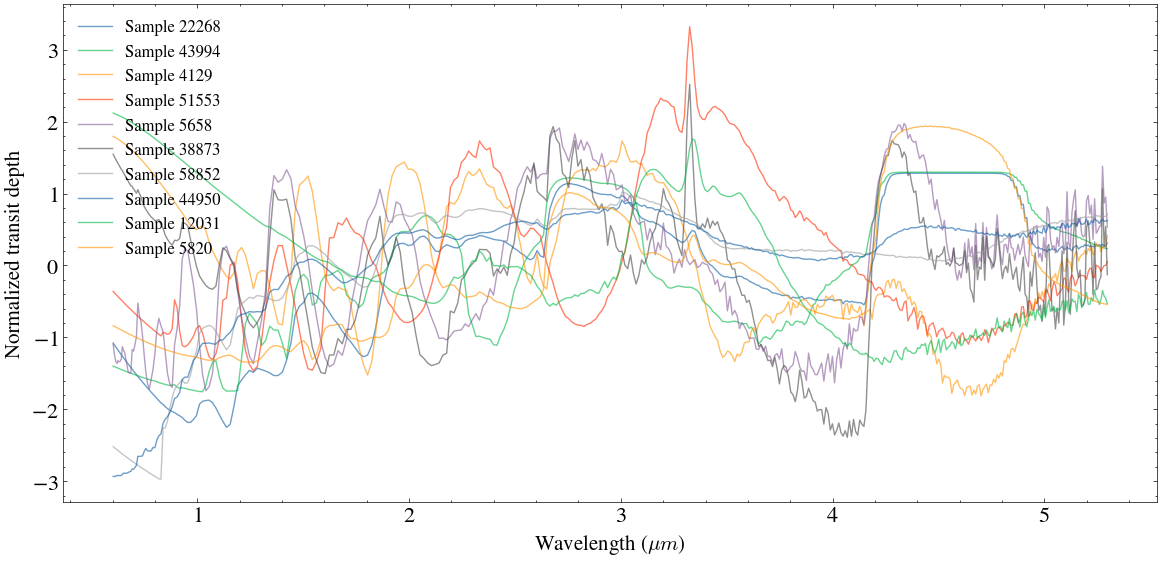

In [16]:
trainer.plot_spectra(wl_grid=wl_grid, scale='row_wise', xlabel='Wavelength ($\mu m$)', ylabel='Normalized transit depth',
                     title='Sample of spectra with normalization scaling', legend_pos='upper left',
                     save_path=dataset_path+'exoCNN_sample_spectra_normalization'
                     )

<>:1: SyntaxWarning: invalid escape sequence '\l'
<>:1: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_599/1456514558.py:1: SyntaxWarning: invalid escape sequence '\l'
  trainer.plot_performance_hist(param_names=['T (K)', '$\log(H_2O)$'], hist=True, cmap='viridis',


Saved: /content/drive/MyDrive/ML Dataset/Transmission Datasets/exoCNN/exoCNN_true_vs_pred_normalization_NEW_T_(K).pdf


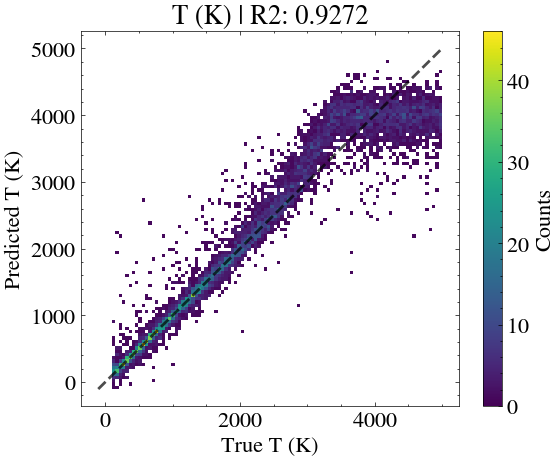

Saved: /content/drive/MyDrive/ML Dataset/Transmission Datasets/exoCNN/exoCNN_true_vs_pred_normalization_NEW_$\log(H_2O)$.pdf


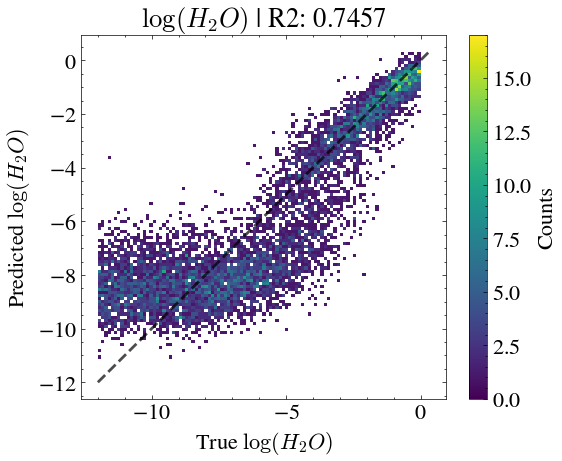

In [ ]:
trainer.plot_performance_hist(param_names=['T (K)', '$\log(H_2O)$'], hist=True, cmap='viridis',
                         save_path=dataset_path+'exoCNN_true_vs_pred_normalization_NEW.pdf'
                         )

### Standard Scaler

In [17]:
model = XGBRegressor(
    n_estimators=1,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    early_stopping_rounds=100,
    n_jobs=-1,
    device='cuda'
)
trainer = MLTrainer(model, feature_scaler='standard', target_scaler='standard')
trainer.run(X, Y, test_size=0.1, val_size=0.1)

--- Starting Regression Pipeline with XGBRegressor ---


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [09:14:08] WARNING: /__w/xgboost/xgboost/src/context.cc:55: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()
/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:385: UserWarning: [09:14:08] WARNING: /__w/xgboost/xgboost/src/context.cc:210: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()


Global RMSE: 998.3738 | Global R2: 0.0032


# Tuning

In [ ]:
param_grid = {
    'n_estimators': [1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [6, 8, 10],
    'early_stopping_rounds': [100],
}
trainer.optimize_hyperparameters(param_grid, cv=3)

--- Starting Hyperparameter Optimization (GridSearchCV) ---
Fitting 3 folds for each of 9 candidates, totalling 27 fits
[0]	validation_0-rmse:0.99901
[1]	validation_0-rmse:0.99693
[2]	validation_0-rmse:0.99480
[3]	validation_0-rmse:0.99324
[4]	validation_0-rmse:0.99170
[5]	validation_0-rmse:0.99029
[6]	validation_0-rmse:0.98878
[7]	validation_0-rmse:0.98770
[8]	validation_0-rmse:0.98636
[9]	validation_0-rmse:0.98552
[10]	validation_0-rmse:0.98471
[11]	validation_0-rmse:0.98380
[12]	validation_0-rmse:0.98266
[13]	validation_0-rmse:0.98146
[14]	validation_0-rmse:0.98075
[15]	validation_0-rmse:0.97943
[16]	validation_0-rmse:0.97864
[17]	validation_0-rmse:0.97726
[18]	validation_0-rmse:0.97615
[19]	validation_0-rmse:0.97526
[20]	validation_0-rmse:0.97493
[21]	validation_0-rmse:0.97397
[22]	validation_0-rmse:0.97284
[23]	validation_0-rmse:0.97191
[24]	validation_0-rmse:0.97121
[25]	validation_0-rmse:0.97026
[26]	validation_0-rmse:0.96993
[27]	validation_0-rmse:0.96922
[28]	validation_0-rmse

In [ ]:
model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=8,
    random_state=42,
    early_stopping_rounds=100,
    n_jobs=-1,
    device='cuda'
)
trainer = MLTrainer(model, feature_scaler='standard', target_scaler='standard')
trainer.run(X, Y, test_size=0.1, val_size=0.1)

--- Starting Regression Pipeline with XGBRegressor ---
Global RMSE: 818.9282 | Global R2: 0.2674


<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2628/2896227903.py:1: SyntaxWarning: invalid escape sequence '\m'
  trainer.plot_spectra(wl_grid=wl_grid, scale='standard', xlabel='Wavelength ($\mu m$)', ylabel='Standardized transit depth', title='',


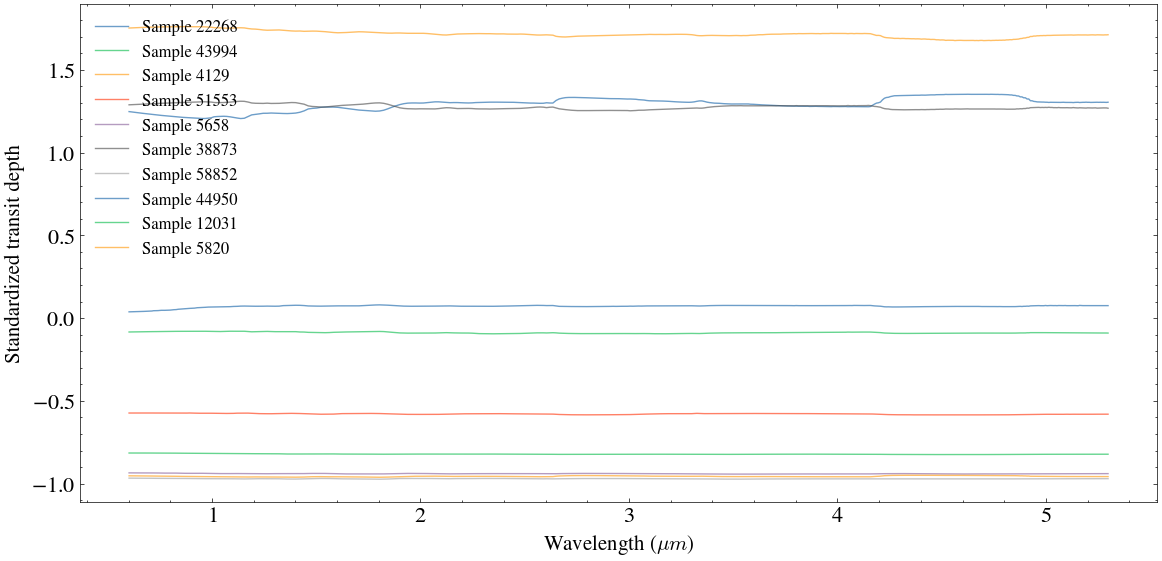

In [20]:
trainer.plot_spectra(wl_grid=wl_grid, scale='standard', xlabel='Wavelength ($\mu m$)', ylabel='Standardized transit depth', title='',
                     legend_pos='upper left',
                     save_path=dataset_path+'exoCNN_sample_spectra_standardization'
                     )

<>:1: SyntaxWarning: invalid escape sequence '\l'
<>:1: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_599/1222172304.py:1: SyntaxWarning: invalid escape sequence '\l'
  trainer.plot_performance_hist(param_names=['T (K)', '$\log(H_2O)$'], cmap='viridis',


Saved: /content/drive/MyDrive/ML Dataset/Transmission Datasets/exoCNN/exoCNN_true_vs_pred_standardization_NEW_T_(K).pdf


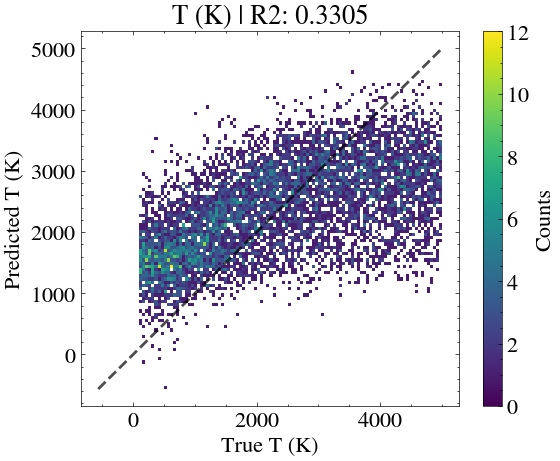

Saved: /content/drive/MyDrive/ML Dataset/Transmission Datasets/exoCNN/exoCNN_true_vs_pred_standardization_NEW_$\log(H_2O)$.pdf


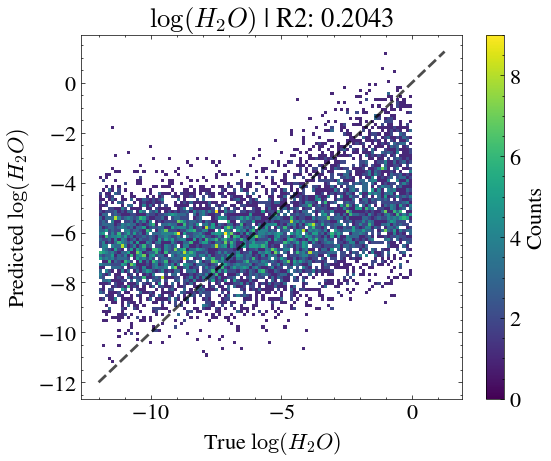

In [ ]:
trainer.plot_performance_hist(param_names=['T (K)', '$\log(H_2O)$'], cmap='viridis',
                         save_path=dataset_path+'exoCNN_true_vs_pred_standardization_NEW.pdf'
                         )